In [1]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader, Subset
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [3]:
model = CNN(width=6, bn=True, normalise=False)
device = torch.device("mps")
results_dir = TRAINING_RESULTS / 'ext_high_mass' / 'good_runs' /'run_210626_163120'
weights_path = results_dir /'best_model_weights.pth'
#weights_path = results_dir / 'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=12288, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

In [4]:
DEVICE = torch.device("mps")
def accuracy(model, loader, threshold=0.5):
    model.eval()
    
    soft_correct, hard_correct, soft_total, hard_total = 0, 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            images, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > threshold).float()
            soft_correct += (predicted == labels).sum().item()
            hard_correct += ((predicted == labels).all(dim=1)).sum().item()
            soft_total += labels.numel()
            hard_total += labels.size(0)
    
    soft_acc = soft_correct/soft_total
    hard_acc = hard_correct/hard_total
    return soft_acc, hard_acc

In [5]:
dataset = LISADataset(training_ehm_dataset_path)

unique_indices = np.unique(dataset.sim_indices)
all_indices = np.array(dataset.sim_indices)

rng = np.random.default_rng(42)
rng.shuffle(unique_indices)

n_total = len(unique_indices)
n_train = int(0.7 * n_total)
n_val   = int(0.2 * n_total)

train_sources = unique_indices[:n_train]
val_sources   = unique_indices[n_train:n_train+n_val]
test_sources  = unique_indices[n_train+n_val:]

train_indices = np.where(np.isin(all_indices, train_sources))[0]
val_indices   = np.where(np.isin(all_indices, val_sources))[0]
test_indices  = np.where(np.isin(all_indices, test_sources))[0]

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

In [7]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1]

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())
        all_labels.append(labels)

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)
probs = torch.cat(all_probs)

In [15]:
from sklearn.metrics import roc_curve, auc

probs = np.array(probs)
labels = np.array(labels)

fpr_gw, tpr_gw, _ = roc_curve(
    labels[:, 0],
    probs[:, 0]
)
fpr_glitch, tpr_glitch, _ = roc_curve(
    labels[:, 1],
    probs[:, 1]
)
auc_gw = auc(fpr_gw, tpr_gw)
auc_glitch = auc(fpr_glitch, tpr_glitch)

print("GW AUC =", auc_gw)
print("Glitch AUC =", auc_glitch)

np.savez(results_dir / 'roc_curves.npz',
         fpr_gw=fpr_gw,
        tpr_gw=tpr_gw,
        auc_gw=auc_gw,
        fpr_glitch=fpr_glitch,
        tpr_glitch=tpr_glitch,
        auc_glitch=auc_glitch)

GW AUC = 0.9993970000000001
Glitch AUC = 0.98066


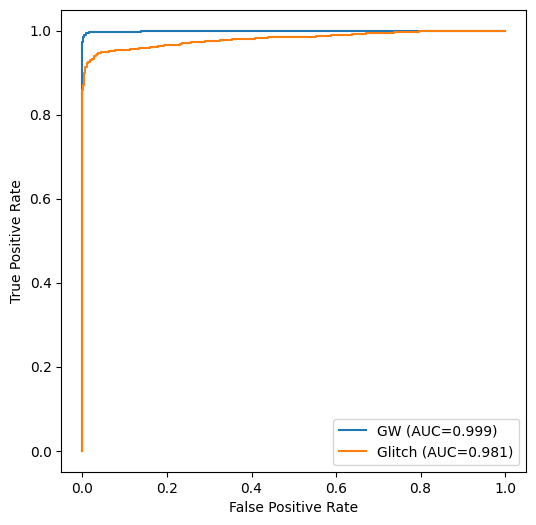

In [13]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr_gw,
    tpr_gw,
    label=f'GW (AUC={auc_gw:.3f})'
)

plt.plot(
    fpr_glitch,
    tpr_glitch,
    label=f'Glitch (AUC={auc_glitch:.3f})'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

In [8]:
train_loader = DataLoader(train_dataset, batch_size=64)
train_soft_acc, train_hard_acc = accuracy(model, train_loader)

val_loader = DataLoader(val_dataset, batch_size=64)
val_soft_acc, val_hard_acc = accuracy(model, val_loader)

test_loader = DataLoader(test_dataset, batch_size=64)
test_soft_acc, test_hard_acc = accuracy(model, test_loader)

print(f"Training Soft Accuracy: {train_soft_acc:.4f}, Training Hard Accuracy: {train_hard_acc:.4f}")
print(f"Validation Soft Accuracy: {val_soft_acc:.4f}, Validation Hard Accuracy: {val_hard_acc:.4f}")
print(f"Test Soft Accuracy: {test_soft_acc:.4f}, Test Hard Accuracy: {test_hard_acc:.4f}")

Training Soft Accuracy: 0.9972, Training Hard Accuracy: 0.9945
Validation Soft Accuracy: 0.9660, Validation Hard Accuracy: 0.9325
Test Soft Accuracy: 0.9732, Test Hard Accuracy: 0.9470


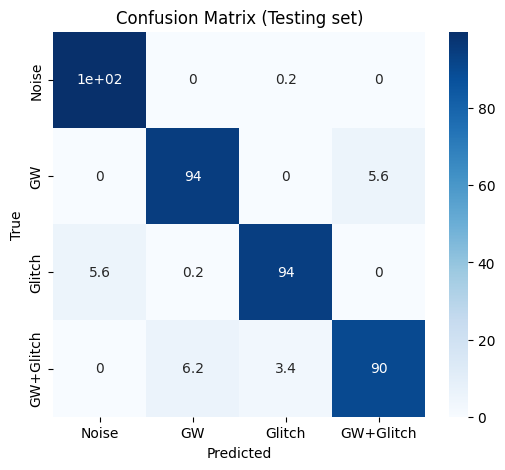

In [7]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class, normalize='true')*100
np.savez(results_dir / 'confusion_matrix.npz', cm=cm)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

In [8]:
np.where((true_class == 3)&(pred_class == 2))[0]

array([ 705,  706,  707,  708,  709,  710,  711,  712,  713,  714,  729,
        757,  758,  759,  760,  768,  769,  785,  786,  789,  790,  816,
        825,  826,  836,  838,  839,  865,  885,  887,  888,  889,  900,
        919,  960,  975,  979, 1005, 1006, 1007, 1008, 1009])

In [16]:
wrong = np.where((true_class == 3)&(pred_class == 2))[0]
wrong_sims = [test_dataset[i][2] for i in wrong]

right = np.where((true_class == 3)&(pred_class == 2))[0]
right_sims = np.array([test_dataset[i][2] for i in right])

In [17]:
wrong_times = np.array([test_dataset[i][3] for i in wrong])

In [18]:
with h5py.File(gw_ehm_dataset_path, 'r') as f:
    QT_arr = f['QT'][:]
    t_arr = f['t_qscan'][:]
    f_arr = f['f_qscan'][:]
    X_arr = f['X'][:]
    Y_arr = f['Y'][:]
    Z_arr = f['Z'][:]
    m1 = f['m1'][:]
    m2 = f['m2'][:]
    d = f['d'][:]
    spin1 = f['spin1'][:]
    spin2 = f['spin2'][:]
    gw_beta = f['gw_beta'][:]
    gw_lambda = f['gw_lambda'][:]
    tcen_arr = f['tcen'][:]

In [19]:
wrong_images = QT_arr[wrong_sims, wrong_times, :, :, :]
wrong_taxes = t_arr[wrong_sims, wrong_times]
wrong_faxes = f_arr[wrong_sims, wrong_times]
wrong_X = X_arr[wrong_sims]
wrong_Y = Y_arr[wrong_sims]
wrong_Z = Z_arr[wrong_sims]
wrong_m1 = m1[wrong_sims]
wrong_m2 = m2[wrong_sims]
wrong_d = d[wrong_sims]
wrong_spin1 = spin1[wrong_sims]
wrong_spin2 = spin2[wrong_sims]
wrong_gw_beta = gw_beta[wrong_sims]
wrong_gw_lambda = gw_lambda[wrong_sims]
wrong_tcen = tcen_arr[wrong_sims]

len(wrong_tcen)

42

In [21]:
index = 2
t_axis = wrong_taxes[index]/3600
f_axis = wrong_faxes[index]
image = wrong_images[index, :, :, 0]
X = wrong_X[index]
Y = wrong_Y[index]
Z = wrong_Z[index]
m1 = wrong_m1[index]
m2 = wrong_m2[index]
d = wrong_d[index]
spin1 = wrong_spin1[index]
spin2 = wrong_spin2[index]
gw_beta = wrong_gw_beta[index]
gw_lambda = wrong_gw_lambda[index]

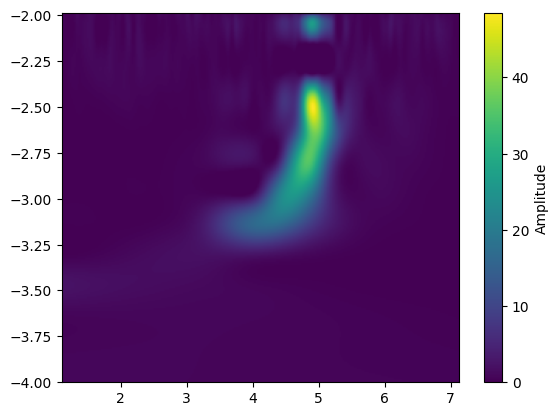

In [22]:
plt.imshow(image, extent=[t_axis[0], t_axis[-1], np.log10(f_axis[0]), np.log10(f_axis[-1])], aspect='auto', origin='lower')
plt.colorbar(label='Amplitude')
plt.show()

In [14]:
A,E,T = get_AET(X, Y, Z)
psd_data = np.load(PSD_PATH / 'psd_A.npz')
f_noise, psd_noise = psd_data['f_psd'], psd_data['psd']

freqs = np.fft.rfftfreq(A.size, 0.25)
# FFT of data
data_fft = np.fft.rfft(A)

f_psd, psd = estimate_psd(A, 1/0.25, nperseg=1e4/0.25, noverlap=None)
Anew = whiten_with_psd(A, 0.25, f_psd, psd, apply_window=True, alpha=0.05)
f_psd_new, psd_new = estimate_psd(Anew, 1/0.25, nperseg=1e4/0.25, noverlap=None)

freqs_new = np.fft.rfftfreq(Anew.size, 0.25)
# FFT of data
data_fft_new = np.fft.rfft(Anew)

#plt.plot(freqs_new, np.real(data_fft_new))
plt.plot(freqs, np.abs(data_fft), label='Original FFT')
#plt.plot(f_psd, np.sqrt(psd), label='Original PSD')
plt.plot(freqs_new, np.sqrt(data_fft_new), label='Whitened FFT')
plt.plot(f_noise, np.sqrt(psd_noise), label='Noise ASD')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
#plt.ylabel('ASD')
#plt.title('Estimated Power Spectral Density')
#plt.ylim(1e-10, 1e-1)
plt.legend()
plt.grid()
plt.show()

NameError: name 'get_AET' is not defined

In [23]:
from helpers.simulation import *

orbits_path2 = str(DIST / 'orbits' / 'orbits2.h5')
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']
    
pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(10 * 3600 / 0.25),
        't_inj': 5 * 3600, 'keep_noises': ['test-mass', 'oms']}

gws = [{'type': 'BinaryInspiralGW', 'm1': m1, 'm2': m2, 'd': d,
        'spin1': spin1, 'spin2': spin2, 't_inj': pipe['t_inj']+sep*3600, 'domain': 'freq',
        'gw_beta':gw_beta, 'gw_lambda':gw_lambda}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': pipe['t_inj']-sep*3600, 'beta': beta,
             'level':2*amp*beta, 'inj_point':inj_point.decode('utf-8')}]

run_simulation(
            gws, glitches, pipe,
            gw_path, glitch_path, orbits_path,
            simulation_path,
            disable_noise=['test-mass', 'oms']
        )
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [ ]:
chirp_mass(7e6, 7e6)/1e6

In [26]:
from helpers.qtransform import *

event = {'t_inj':pipe['t_inj']}
res = 256
spec = SPECS['ext_high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

QT_mixed = np.zeros((256, 256, 3))
for channel in ['A', 'E', 'T']:
    t_mixed, f_mixed, data = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=(1e-4, 1e-2), trange=(-3, 3), Q=6)
    QT_mixed[:, :, ['A', 'E', 'T'].index(channel)] = data


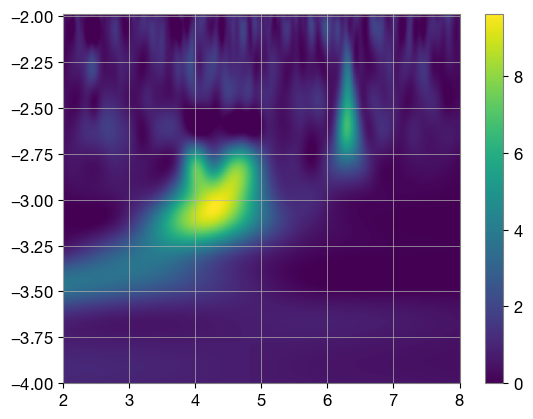

In [28]:
plt.imshow(QT_mixed[:, :, 0], extent=[t_mixed[0]/3600, t_mixed[-1]/3600, np.log10(f_mixed[0]), np.log10(f_mixed[-1])], aspect='auto', origin='lower')
plt.colorbar()
#plt.clim(0, 5)
plt.show()

In [ ]:
X, Y, Z = raw_dict['X'].value, raw_dict['Y'].value, raw_dict['Z'].value
A,E,T = get_AET(X, Y, Z)
psd_data = np.load(PSD_PATH / 'psd_A.npz')
f_noise, psd_noise = psd_data['f_psd'], psd_data['psd']

freqs = np.fft.rfftfreq(A.size, 0.25)
# FFT of data
data_fft = np.fft.rfft(A)

f_psd, psd = estimate_psd(A, 1/0.25, nperseg=1e4/0.25, noverlap=None)
Anew = whiten_with_psd(A, 0.25, f_psd, psd, apply_window=True, alpha=0.05)
f_psd_new, psd_new = estimate_psd(Anew, 1/0.25, nperseg=1e4/0.25, noverlap=None)

freqs_new = np.fft.rfftfreq(Anew.size, 0.25)
# FFT of data
data_fft_new = np.fft.rfft(Anew)

#plt.plot(freqs_new, np.real(data_fft_new))
plt.plot(freqs, np.abs(data_fft), label='Original FFT')
#plt.plot(f_psd, np.sqrt(psd), label='Original PSD')
plt.plot(freqs_new, np.sqrt(data_fft_new), label='Whitened FFT')
plt.plot(f_noise, np.sqrt(psd_noise), label='Noise ASD')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
#plt.ylabel('ASD')
#plt.title('Estimated Power Spectral Density')
#plt.ylim(1e-10, 1e-1)
plt.legend()
plt.grid()
plt.show()

(4.0, 6.0)

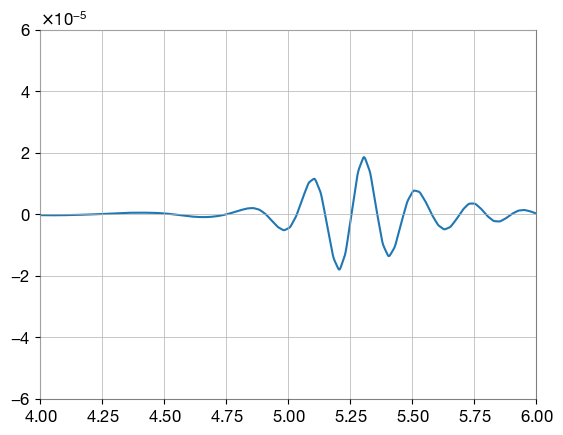

In [16]:
t = raw_dict['X'].times
y = raw_dict['X'].value
plt.plot((t-t[0])/3600, y)
plt.xlim(4, 6)

In [ ]:
gw = BinaryInspiralGW(m1=7e6, m2=7e6, d=1e4, spin1=0, spin2=0, orbits=orbits_path,
                       t_inj=5*3600, domain='freq', gw_beta=0, gw_lambda=np.pi/2)

t = np.arange(0, 10*3600, 0.25)
y = gw.compute_hcross(t)
plt.scatter(t/3600, y, s=5)
plt.xlim(4, 6)

In [32]:
from pycbc.waveform import get_fd_waveform, get_td_waveform

m1, m2 = 7e6, 7e6

c = 3e8
G = 6.67e-11
M = (m1 + m2)*2e30
r = 6
flower = (c**3)/(((6*r)**1.5)*np.pi*G*M)
hp_fd, hc_fd = get_fd_waveform(approximant="IMRPhenomXHM", inclination=np.pi,
                                       mass1=m1, mass2=m2, delta_f=flower/1e3,
                                       f_lower=flower, f_upper=2, distance=1e4, 
                                           spin1z = 0.7, spin2z = 0.7)
hp = hp_fd.to_timeseries()
hc = hc_fd.to_timeseries()

In [ ]:
help(get_fd_waveform)

Help on function get_fd_waveform in module pycbc.waveform.waveform:

get_fd_waveform(template=None, **kwargs)
    Return a frequency domain gravitational waveform.
    
    Parameters
    ----------
    template: object
        An object that has attached properties. This can be used to substitute
        for keyword arguments. A common example would be a row in an xml table.
    
        mass1 : {None, float}
        The mass of the first component object in the binary (in solar masses).
    mass2 : {None, float}
        The mass of the second component object in the binary (in solar masses).
    spin1x : {0.0, float}
        The x component of the first binary component's dimensionless spin.
    spin1y : {0.0, float}
        The y component of the first binary component's dimensionless spin.
    spin1z : {0.0, float}
        The z component of the first binary component's dimensionless spin.
    spin2x : {0.0, float}
        The x component of the second binary component's dimensionl

: 

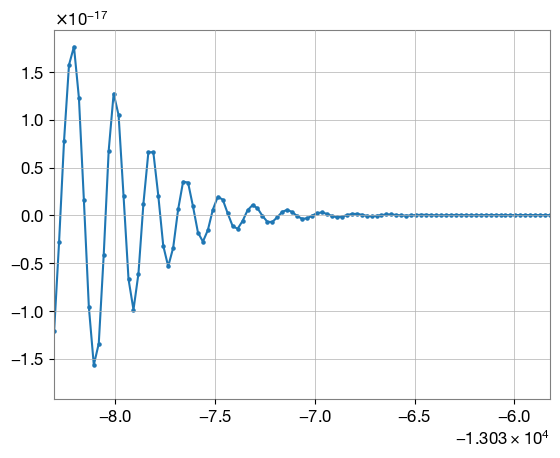

In [33]:
plt.scatter(hp.sample_times/3600, hp.data, s=5)
plt.plot(hp.sample_times/3600, hp.data)
plt.xlim(hp.sample_times[0]/3600, hp.sample_times[100]/3600)
plt.show()

In [23]:
with h5py.File(gw_ehm_dataset_path, 'r+') as h5:
    del h5['QT']
    del h5['t_qscan']
    del h5['f_qscan']
    del h5['tcen']